In [2]:
# Second-Order Voronoi Map of Fire Stations in Township Area

# Cell 1: Install packages if not already installed
!pip install geopandas osmnx shapely matplotlib scipy

In [3]:
# Cell 2: Imports
import geopandas as gpd
import osmnx as ox
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import Point
from shapely.ops import unary_union
from itertools import combinations

In [4]:
# Cell 3: Load township boundary (replace with your file path)
township = gpd.read_file("/Users/toddtrimble/workspace/fire_voronoi/Local_Boundaries_Minor_Civil_Divisions/Minor_Civil_Divisions_IN.shp")
is_shelby = township['Cnty_Name']=="Shelby"
township = township[is_shelby]

In [5]:
# Reproject to WGS84 for osmnx
if township.crs is None:
    township.set_crs(epsg=4326, inplace=True)
elif township.crs.to_epsg() != 4326:
    township = township.to_crs(epsg=4326)

In [6]:
# Cell 4: Load OSM road network inside the township polygon
township_union = township.unary_union
G = ox.graph_from_polygon(township_union, network_type='drive')
roads = ox.graph_to_gdfs(G, nodes=False, edges=True)

/var/folders/h_/p7p1bff12fd3sn_17dbl3ltr0000gn/T/ipykernel_85002/1510576967.py:2: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  township_union = township.unary_union


In [7]:
# Cell 5: Define fire station coordinates (user-supplied)
fire_station_coords = [
    (-85.9070139, 39.6387254), (-85.9709754, 39.529953),
    (-85.8810707, 39.4406702), (-85.7786288, 39.5227097), 
    (-85.9990409, 39.6040567), (-85.779439, 39.6937218)
]

fire_stations = gpd.GeoDataFrame(
    geometry=[Point(xy) for xy in fire_station_coords],
    crs="EPSG:4326"
).to_crs(epsg=3857)

# Project township and roads to same CRS
township = township.to_crs(epsg=3857)
roads = roads.to_crs(epsg=3857)
township_union_proj = township.unary_union

/var/folders/h_/p7p1bff12fd3sn_17dbl3ltr0000gn/T/ipykernel_85002/2813324531.py:16: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  township_union_proj = township.unary_union


In [8]:
# Cell 6: Compute second-order Voronoi regions (approximation with buffers)
def second_order_voronoi(points, boundary_polygon):
    coords = np.array([pt.coords[0] for pt in points])
    pairs = list(combinations(range(len(points)), 2))
    result = {}

    for i, j in pairs:
        pi, pj = coords[i], coords[j]
        midpoint = (pi + pj) / 2
        region = Point(midpoint).buffer(5000)  # Approx. 5 km buffer for display
        clipped = region.intersection(boundary_polygon)
        result[(i, j)] = clipped

    return result

second_order_regions = second_order_voronoi(fire_stations.geometry, township_union_proj)

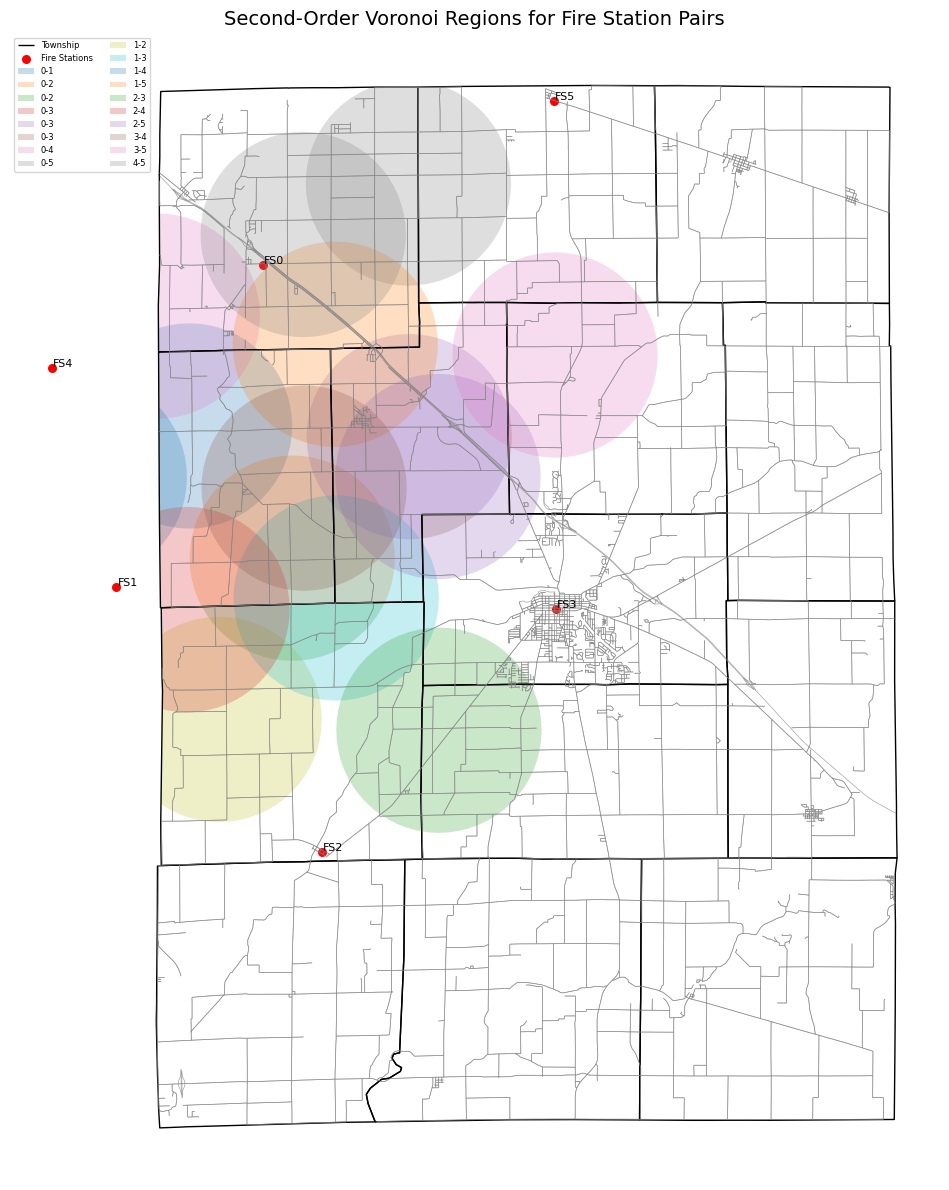

In [9]:
# Cell 7: Plotting
fig, ax = plt.subplots(figsize=(12, 12))

township.boundary.plot(ax=ax, color='black', linewidth=1, label='Township')
roads.plot(ax=ax, color='gray', linewidth=0.5, alpha=0.7)
fire_stations.plot(ax=ax, color='red', markersize=30, label='Fire Stations')

# Plot Voronoi regions
for (i, j), region in second_order_regions.items():
    if region.is_empty:
        continue
    if region.geom_type == 'Polygon':
        ax.fill(*region.exterior.xy, alpha=0.25, label=f'{i}-{j}')
    elif region.geom_type == 'MultiPolygon':
        for poly in region.geoms:
            ax.fill(*poly.exterior.xy, alpha=0.25, label=f'{i}-{j}')

# Label fire stations
for idx, row in fire_stations.iterrows():
    ax.annotate(f'FS{idx}', (row.geometry.x + 50, row.geometry.y + 50), fontsize=8)

ax.set_title("Second-Order Voronoi Regions for Fire Station Pairs", fontsize=14)
ax.set_axis_off()
plt.legend(loc='upper left', fontsize=6, ncol=2)
plt.tight_layout()
plt.show()

In [17]:
# Fire station coordinates as GeoDataFrame
from shapely.geometry import Point

fire_station_coords = [
    # (-85.8572277, 39.5844416),
    (-85.9070139, 39.6387254),
    (-85.9709754, 39.529953),
    (-85.8810707, 39.4406702),
    (-85.7786288, 39.521443)
]
fire_stations = gpd.GeoDataFrame(geometry=[Point(xy) for xy in fire_station_coords], crs="EPSG:4326").to_crs(township.crs)


In [18]:
from scipy.spatial import Voronoi
from shapely.geometry import Polygon
import numpy as np

def bounded_voronoi_regions(vor, radius=1e6):
    new_regions = []
    center = vor.points.mean(axis=0)
    ptp_bound = np.ptp(vor.points, axis=0)
    radius *= ptp_bound.max()

    all_ridges = {}
    for (p1, p2), (v1, v2) in zip(vor.ridge_points, vor.ridge_vertices):
        all_ridges.setdefault(p1, []).append((p2, v1, v2))
        all_ridges.setdefault(p2, []).append((p1, v1, v2))

    for p1, region_idx in enumerate(vor.point_region):
        vertices = vor.regions[region_idx]
        if all(v >= 0 for v in vertices):
            new_regions.append(Polygon([vor.vertices[v] for v in vertices]))
            continue

        region = []
        ridges = all_ridges[p1]
        for p2, v1, v2 in ridges:
            if v1 >= 0 and v2 >= 0:
                region.append(vor.vertices[v2])
                continue
            t = vor.points[p2] - vor.points[p1]
            t /= np.linalg.norm(t)
            n = np.array([-t[1], t[0]])
            midpoint = vor.points[[p1, p2]].mean(axis=0)
            direction = np.sign(np.dot(midpoint - center, n)) * n
            if v1 >= 0:
                far_point = vor.vertices[v1] + direction * radius
                region.append(vor.vertices[v1])
                region.append(far_point)
            elif v2 >= 0:
                far_point = vor.vertices[v2] + direction * radius
                region.append(vor.vertices[v2])
                region.append(far_point)
        new_regions.append(Polygon(region))
    return new_regions

coords = np.array([(p.x, p.y) for p in fire_stations.geometry])
vor = Voronoi(coords)
regions = bounded_voronoi_regions(vor)
station_voronoi = gpd.GeoDataFrame(geometry=regions, crs=fire_stations.crs)


In [19]:
from itertools import combinations
from shapely.ops import unary_union

second_order_polygons = []
station_pairs = list(combinations(range(len(fire_stations)), 2))

for i, j in station_pairs:
    poly_i = station_voronoi.iloc[i].geometry
    poly_j = station_voronoi.iloc[j].geometry
    intersect = poly_i.intersection(poly_j)
    if not intersect.is_empty:
        clipped = intersect.intersection(township.unary_union)
        second_order_polygons.append({
            'geometry': clipped,
            'stations': (i, j)
        })

second_order_gdf = gpd.GeoDataFrame(second_order_polygons, crs=fire_stations.crs)


/var/folders/h_/p7p1bff12fd3sn_17dbl3ltr0000gn/T/ipykernel_85002/3515259017.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  clipped = intersect.intersection(township.unary_union)


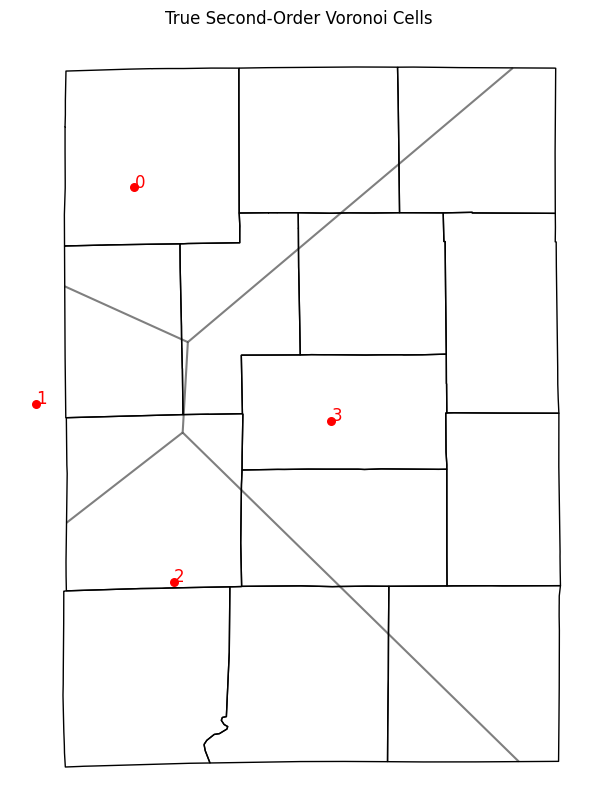

In [20]:
fig, ax = plt.subplots(figsize=(10, 10))
township.boundary.plot(ax=ax, color='black', linewidth=1)
second_order_gdf.plot(ax=ax, alpha=0.5, edgecolor='k', cmap='tab20')
fire_stations.plot(ax=ax, color='red', markersize=30)
for idx, row in fire_stations.iterrows():
    ax.annotate(str(idx), (row.geometry.x, row.geometry.y), fontsize=12, color='red')
plt.title("True Second-Order Voronoi Cells")
plt.axis('off')
plt.show()


In [21]:
import numpy as np
from shapely.geometry import Point
from collections import defaultdict

# Create a grid of points within the township boundary
minx, miny, maxx, maxy = township.total_bounds
resolution = 200  # smaller means higher resolution

x_coords = np.linspace(minx, maxx, resolution)
y_coords = np.linspace(miny, maxy, resolution)
grid_points = [Point(x, y) for x in x_coords for y in y_coords]
grid_points = [pt for pt in grid_points if township.unary_union.contains(pt)]

# Assign each point to the nearest pair of stations
def closest_two_stations(pt, station_points):
    dists = [pt.distance(s) for s in station_points]
    idx = np.argsort(dists)[:2]
    return tuple(sorted(idx))

station_points = fire_stations.geometry.tolist()
pair_bins = defaultdict(list)

for pt in grid_points:
    pair = closest_two_stations(pt, station_points)
    pair_bins[pair].append(pt)


/var/folders/h_/p7p1bff12fd3sn_17dbl3ltr0000gn/T/ipykernel_85002/1332368493.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  grid_points = [pt for pt in grid_points if township.unary_union.contains(pt)]


In [22]:
from shapely.ops import unary_union
import geopandas as gpd

second_order_regions = []

for pair, pts in pair_bins.items():
    if len(pts) < 3:
        continue
    gdf = gpd.GeoSeries(pts)
    buffered = gdf.buffer((maxx - minx) / resolution / 2)
    merged = unary_union(buffered)
    region = merged.intersection(township.unary_union)
    second_order_regions.append({
        'geometry': region,
        'stations': pair
    })

second_order_gdf = gpd.GeoDataFrame(second_order_regions, crs=fire_stations.crs)


/var/folders/h_/p7p1bff12fd3sn_17dbl3ltr0000gn/T/ipykernel_85002/654485698.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  region = merged.intersection(township.unary_union)
/var/folders/h_/p7p1bff12fd3sn_17dbl3ltr0000gn/T/ipykernel_85002/654485698.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  region = merged.intersection(township.unary_union)
/var/folders/h_/p7p1bff12fd3sn_17dbl3ltr0000gn/T/ipykernel_85002/654485698.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  region = merged.intersection(township.unary_union)
/var/folders/h_/p7p1bff12fd3sn_17dbl3ltr0000gn/T/ipykernel_85002/654485698.py:12: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  region = merged.intersection(township.unary_union)
/var/folders/h_/p7p1bff12fd3sn_17dbl3ltr0000gn/T/ipykern

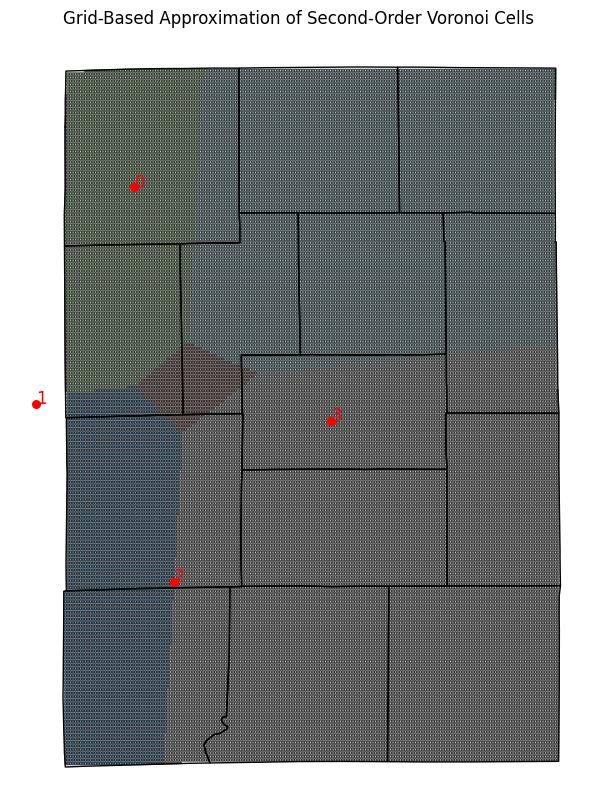

In [23]:
fig, ax = plt.subplots(figsize=(10, 10))
township.boundary.plot(ax=ax, color='black', linewidth=1)
second_order_gdf.plot(ax=ax, alpha=0.6, edgecolor='k', cmap='tab20')
fire_stations.plot(ax=ax, color='red', markersize=30)
for idx, row in fire_stations.iterrows():
    ax.annotate(str(idx), (row.geometry.x, row.geometry.y), fontsize=12, color='red')
plt.title("Grid-Based Approximation of Second-Order Voronoi Cells")
plt.axis('off')
plt.show()
